### Dependencies

In [48]:
%pip install matplotlib
%pip install numpy
%pip install torch

### Randomness and reproducibility

In [49]:
import numpy as np, random, torch
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### EDA (Exploratory Data Analysis)

In [50]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Number of classes: 4

- Baroque: 1350  samples
- Impressionism: 1350  samples
- Cubism: 1350  samples
- Abstract_Expressionism: 1350  samples

Total: 5400 samples


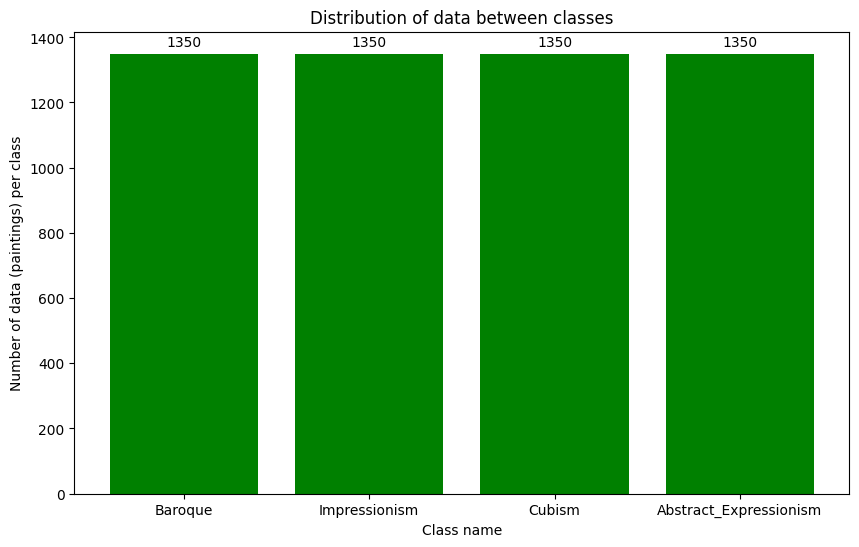

In [51]:
from google.colab import drive
drive.mount('/content/drive/')

data = np.load('/content/drive/MyDrive/Colab Notebooks/prml_project2/wikiart_hw2.npz')
X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of data (paintings) per class")
plt.bar_label(plt.bar(counts.keys(), counts.values(), color='green'), padding=3)
plt.show()

### Device selection

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Creating tensors with data

In [53]:
# loading data into tensors

x_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([5400, 3, 32, 32])
y tensor: torch.Size([5400])


### Train-Val-Test split

Train split: x:torch.Size([3200, 3, 32, 32]) y:torch.Size([3200])
  - Baroque: 800
  - Impressionism: 800
  - Cubism: 800
  - Abstract_Expressionism: 800
Val split:   x:torch.Size([800, 3, 32, 32]) y:torch.Size([800])
  - Baroque: 200
  - Impressionism: 200
  - Cubism: 200
  - Abstract_Expressionism: 200
Test split:  x:torch.Size([1400, 3, 32, 32]) y:torch.Size([1400])
  - Baroque: 350
  - Impressionism: 350
  - Cubism: 350
  - Abstract_Expressionism: 350


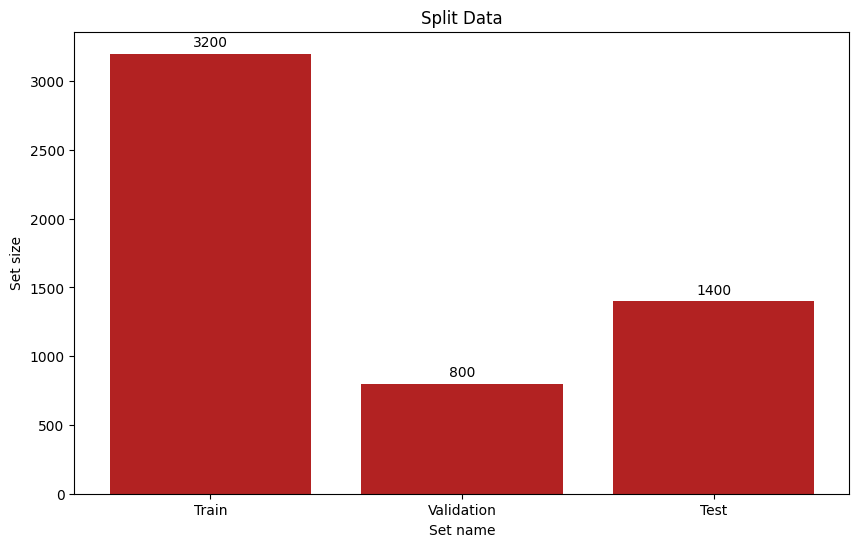

In [54]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.407407407, random_state=SEED, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.63636363, random_state=SEED, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Split Data")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

### Datasets and dataloaders

In [55]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# necessary for reproducibility
# (apparently if this generator isn't used in the training dataloader, reproducibility isn't guaranteed)
g = torch.Generator()
g.manual_seed(SEED)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 200
Validation batches: 50
Test batches: 88


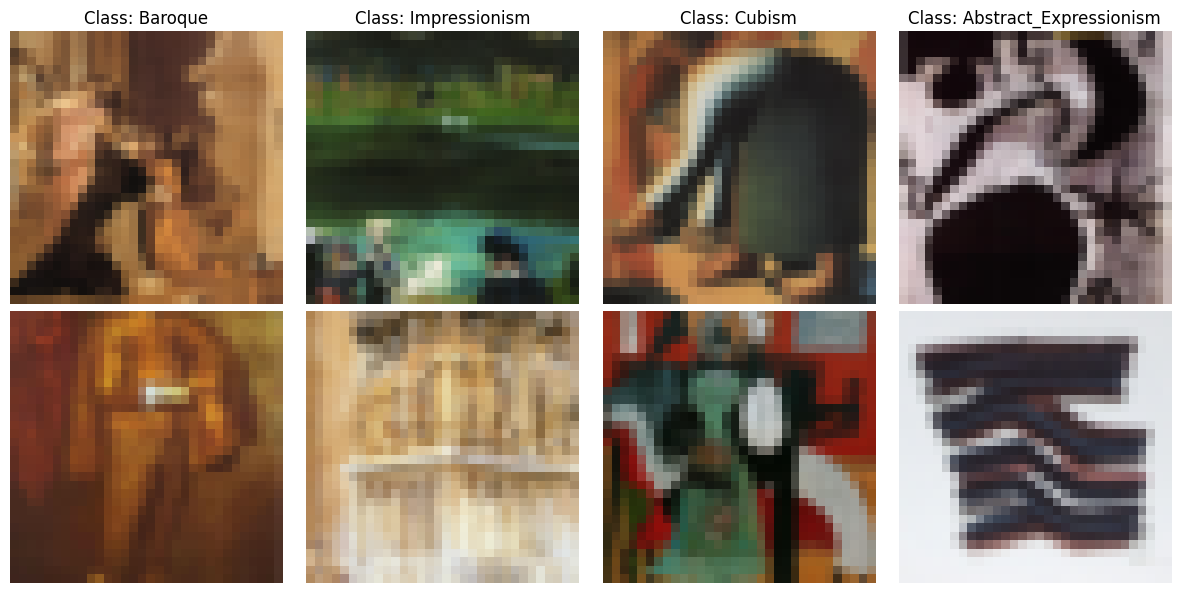

In [56]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 2 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx in range(4):
    for sample_idx in range(2):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Q0.1 Από την οπτικοποίηση, ποια οπτικά γνωρίσματα φαίνεται να διαφοροποιούν περισσότερο τα τέσσερα κινήματα μεταξύ τους (χρωματική παλέτα, υφή, σύνθεση, παρουσία θέματος); Ποια ζευγάρια κλάσεων αναμένετε να είναι πιο εύκολο να μπερδέψει ένας ταξινομητής, και γιατί; Αν ένας άνθρωπος έβλεπε τις ίδιες εικόνες resized σε 32×32, ποιο κίνημα θα ήταν πιο δύσκολο να ξεχωρίσει;
**A: Τα οπτικά γνωρίσματα που διαφοροποιούν περισσότερο τα τέσσερα κινήματα είναι η χρωματική παλέτα και η παρουσία (ή μη) σαφούς θέματος.**  
**- Το Μπαρόκ ξεχωρίζει από τον έντονο, δραματικό φωτισμό (φωτεινό θέμα με σκούρο φόντο), την ζωτικότητα των μορφών.**  
**- Ο Ιμπρεσιονισμός από τις πιο φωτεινές, παστέλ αποχρώσεις και τις υπαίθριες σκηνές.**  
**- O Κυβισμός εστιάζει σε συνθέσεις από γεωμετρικά σχήματα.**  
**- Αφαιρετικός Εξπρεσιονισμός χαρακτηρίζεται από την πλήρη απουσία αναγνωρίσιμου θέματος.**  
**Αναμένουμε ένας ταξινομητής να μπερδέψει πιο εύκολα τον Κυβισμό με τον Αφαιρετικό Εξπρεσιονισμό, καθώς αμφότερα στερούνται ρεαλιστικών αναπαραστάσεων. Αν ένας άνθρωπος έβλεπε τις εικόνες σε ανάλυση 32x32, το πιο δύσκολο κίνημα να ξεχωρίσει θα ήταν πιθανότατα ο Κυβισμός, διότι σε τόσο χαμηλή ανάλυση οι αιχμηρές γεωμετρικές ακμές και οι πολλαπλές οπτικές γωνίες πολτοποιούνται, κάνοντάς τον να μοιάζει με τυχαίες κηλίδες, μπερδεύοντάς τον με Αφαιρετικό Εξπρεσιονισμό.**

### Training-Evaluation functions

In [57]:
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix

class baseline_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=3*32*32, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=4)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = baseline_FNN().to(device)
# debugging
print(model)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass
        logits = model(images)
        # loss calculation
        loss = criterion(logits, labels)
        # backward pass
        loss.backward()
        # weights update
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model(images)
            # losss calculation
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')
    epoch_loss_cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1_macro, epoch_loss_cm


baseline_FNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)


### Training

In [58]:
from torch.optim import Adam
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
cpu_time = -1
gpu_time = -1

EPOCHS = 30
LEARNING_RATE = 0.001
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_f1_val = -1
best_model_path = "best_baseline_fnn.pth"

print("Starting training...\n")

start_time = time.time()

for epoch in range(EPOCHS):
    # train (adjusting weights)
    train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)

    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1>best_f1_val:
        best_f1_val = val_f1
        torch.save(model.state_dict(), best_model_path)

    # current epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)
end_time = time.time()

print(f"Training complete!")
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

Using device: cuda
Starting training...

Epoch [1/30]  Train Loss: 1.3693 | Train Acc: 31.81%  Val Loss:   1.3358 | Val Acc:   37.38% | Val F1: 0.3151
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3262 | Train Acc: 37.03%  Val Loss:   1.3000 | Val Acc:   41.38% | Val F1: 0.3612
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2769 | Train Acc: 39.78%  Val Loss:   1.2709 | Val Acc:   43.38% | Val F1: 0.4063
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.2481 | Train Acc: 42.38%  Val Loss:   1.3782 | Val Acc:   38.00% | Val F1: 0.3322
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.2386 | Train Acc: 42.81%  Val Loss:   1.2676 | Val Acc:   41.88% | Val F1: 0.3727
-----

### Training on CPU

In [59]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    model_cpu = baseline_FNN().to(device)
    optimizer_cpu = Adam(model_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(model_cpu, train_dataloader, optimizer_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 62.30 seconds
GPU was 2.2707 times quicker than the CPU


### Best model evaluation on test set

=======  Baseline FNN model evaluation on TEST SET  =======
Test Loss: 1.2935162019729614
Test Accuracy: 0.48928571428571427
Test F1-macro: 0.48831031208019715
Test Confusion matrix:
[157  37  55 101]
[ 24 186  60  80]
[ 29  60 117 144]
[ 18  54  53 225]



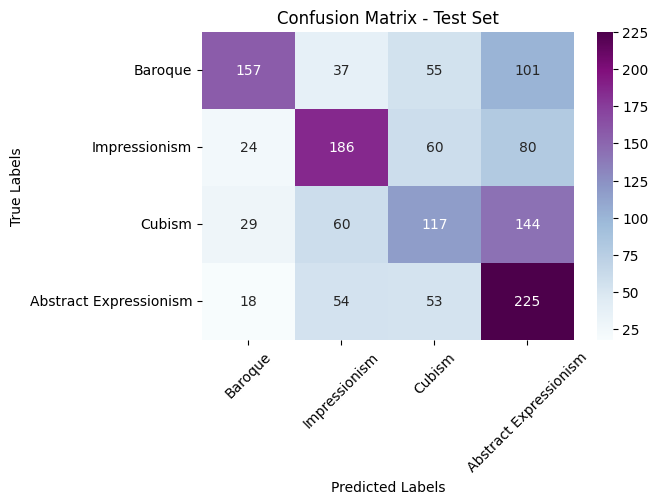

In [60]:
import seaborn as sns

best_model = baseline_FNN().to(device)
best_model.load_state_dict(torch.load("best_baseline_fnn.pth"))

test_loss, test_acc, test_f1, test_cm = evaluate(best_model, test_dataloader, criterion)

cm_fnn = test_cm

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Learning curves (Loss and F1-macro)

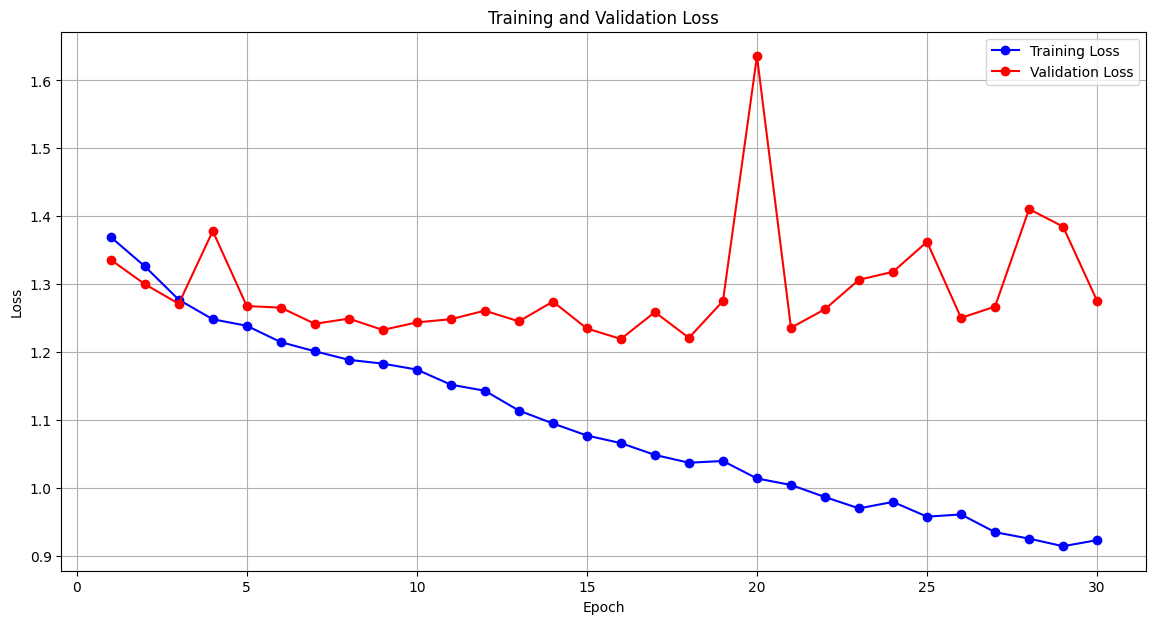

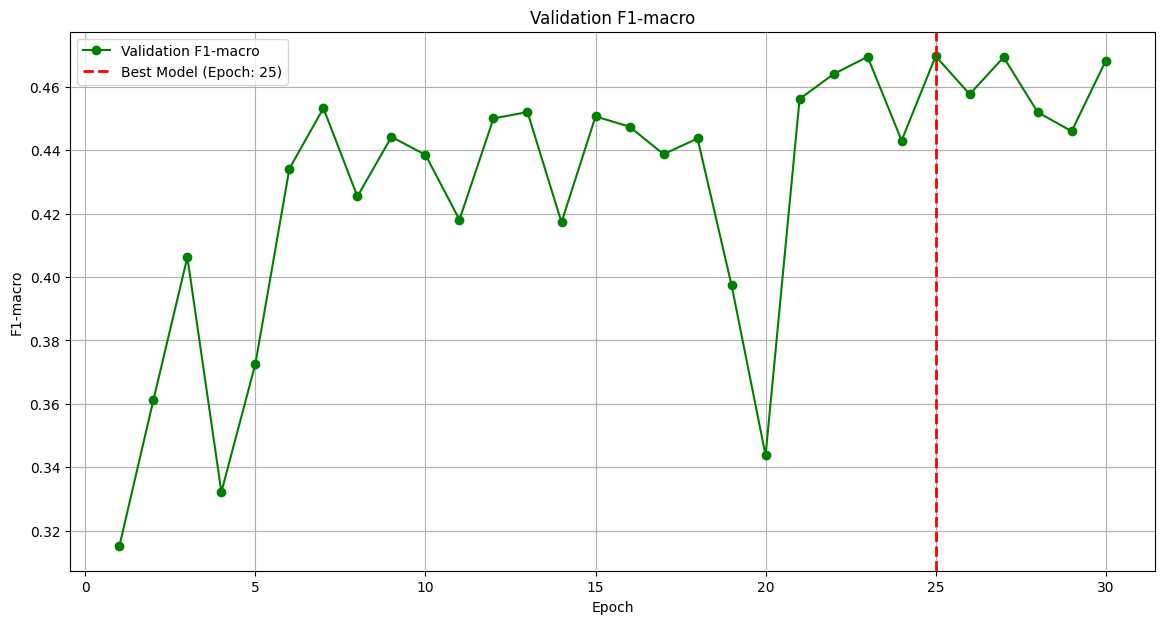

In [61]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['val_f1'])+1), history['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

### Q1.1 Με βάση τα loss curves και την καμπύλη validation F1, παρατηρείτε overfitting, underfitting, ή ισορροπία; Σε ποια εποχή επιλέχθηκε το best model με κριτήριο το validation F1, και σε ποια θα είχε επιλεγεί αν χρησιμοποιούσατε το train loss ως κριτήριο; Γιατί η επιλογή με βάση το validation set είναι κρίσιμη; Ήταν αναμενόμενο το GPU speedup σε σχέση με την εκπαίδευση σε CPU για ένα δίκτυο αυτού του μεγέθους;

**A: Παρατηρώντας τις loss καμπύλες, βλέπουμε ότι ενώ το Training Loss μειώνεται συνεχώς καθώς περνούν οι εποχές, το Validation Loss σταματά να πέφτει και αρχίζει να σταθεροποιείται ή να αυξάνεται ελαφρώς μετά από κάποιο σημείο, με εμφανώς μεγαλύτερες διακυμάνσεις ωστόσο. Αυτό είναι σαφής ένδειξη overfitting, γεγονός που καθιστά κρίσιμη την επιλογή του καλύτερου μοντέλου με βάση το μέγιστο Validation F1-macro. Με αυτόν τον τρόπο κρατάμε την έκδοση του δικτύου στο σημείο που γενικεύει καλύτερα στα άγνωστα δεδομένα, προτού αρχίσει να αποστηθίζει το training set.**  

**Με βάση το κριτήριο του μέγιστου Validation F1-macro, το βέλτιστο μοντέλο επιλέχθηκε στην εποχή 25. Αντίθετα, αν χρησιμοποιούσαμε το Training Loss ως κριτήριο επιλογής, το μοντέλο θα είχε επιλεγεί στην εποχή 29 ή 30 (τις τελευταίες), καθώς εκεί το σφάλμα εκπαίδευσης φτάνει στο απόλυτο ελάχιστο λόγω της αποστήθισης των δεδομένων. Το γεγονός αυτό καθιστά κρίσιμη την επιλογή με βάση το validation set (και μάλιστα validation f1), διότι μας επιτρέπει να "σώσουμε" την έκδοση του δικτύου στο σημείο που γενικεύει καλύτερα στα άγνωστα δεδομένα, ακριβώς πριν αρχίσει να προσαρμόζεται υπερβολικά στον θόρυβο του training set.**

**Όσον αφορά τους χρόνους, το GPU speedup περίπου 200%-300% (ανάλογα με τα resources που τυχαίνουν στο colab ήταν περίπου 2 με 3 φορές ταχύτερη η Τ4 GPU). Κάτι τέτοιο ήταν απολύτως αναμενόμενο για ένα δίκτυο αυτού του μεγέθους. Το Baseline FNN είναι ένα αρκετά "ρηχό" δίκτυο με απλούς πολλαπλασιασμούς πινάκων και η εκπαίδευση έχει μικρό πλήθος δεδομένων. Συνεπώς η χρήση GPU προσφέρει μεν μια σαφή και ικανοποιητική μείωση του χρόνου, αλλά δεν βλέπουμε την τεράστια επιτάχυνση (π.χ. >10x-15x) που θα προέκυπτε σε βαθιά Νευρωνικά Δίκτυα.**

### Q1.2 Παρουσιάστε accuracy, F1 macro, και confusion matrix του best model στο test set. Ποια κινήματα μπερδεύονται περισσότερο μεταξύ τους; Αναδιαμορφώστε (reshape) τα βάρη του πρώτου γραμμικού επιπέδου από σχήμα [128, 3072] σε [128, 3, 32, 32], κανονικοποιήστε κάθε «φίλτρο» στο [0, 1] (min-max ανά φίλτρο), και οπτικοποιήστε 16 από αυτά ως RGB εικόνες σε διάταξη 4×4. Συζητήστε γιατί το flat-pixel FFN δυσκολεύεται παρά την παρουσία της ReLU: τι «βλέπει» κάθε νευρώνας του πρώτου επιπέδου, και ποιο είδος δομής της εικόνας δεν μπορεί να εκμεταλλευτεί αυτή η αρχιτεκτονική;

**A: Accuracy, F1-macro και confusion matrix φαίνονται στο παρακάτω cell.**  

**Παρατηρούμε τα εξής συμπεράσματα για το ποια κινήματα μπερδεύονται περισσότερο (2 περιπτώσεις των περισσότερων σφαλμάτων):**  
1. **Cubism -> Abstract Expressionism (144 λάθη). Πρόκειται για το μεγαλύτερο σφάλμα του δικτύου. 144 πίνακες Κυβισμού ταξινομήθηκαν λανθασμένα ως Αφαιρετικός Εξπρεσιονισμός.**
2. **Baroque -> Abstract Expressionism (101 λάθη). 101 πίνακες Μπαρόκ ταξινομήθηκαν λανθασμένα ως Αφαιρετικός Εξπρεσιονισμός.**  
**Το baseline FNN δυσκολεύεται να διακρίνει τα όρια μεταξύ των κινημάτων, διότι βασίζεται αποκλειστικά σε μεμονωμένες τιμές pixels (με έμμεσο τρόπο και σε συχετίσεις αυτών, ώντας fully connected). Επειδή ο Αφαιρετικός Εξπρεσιονισμός και ο Κυβισμός μοιράζονται συχνά παρόμοιες χρωματικές παλέτες και στερούνται αυστηρού θέματος (π.χ. συγκεκριμένα αντικείμενα ή πρόσωπα), το δίκτυο συχνά αδυνατεί να βρει ξεκάθαρα διαχωριστικά χαρακτηριστικά.**

**Οι οπτικοποιήσεις των νευρώνων μας δείχνουν τι ακριβώς "βλέπουν"/"ψάχνουν":**  
**Λόγω της κανονικοποίησης min-max στο 0-1,**  
- **όσο πιο φωτεινό (τιμές κοντά στο 1) είναι ένα pixel στην οπτικοποίηση (ανεξαρτήτου χρώματος), τόσο περισσότερο ο νευρώνας "ψάχνει" το συγκεκιρμένο χρώμα στο συγκεκριμένο pixel.** ***-->Θετική συσχέτιση***  
- **όσο πιο σκούρο (τιμές κοντά στο 0) είναι ένα pixel στην οπτικοποίηση (ανεξαρτήτου χρώματος), τόσο λιγότερο ο νευρώνας "ψάχνει" το συγκεκριμένο χρώμα στο συγκεκριμένο pixel.** ***-->Αρνητική συσχέτιση***  
- **όταν ένα pixel στην οπτικοποίηση μοιάζει ξεθωριασμένο/μουντό/γκρίζο (τιμές κοντά στο 0.5) (ανεξαρτήτου χρώματος), τότε σημαίνει ότι ο νευρώνας αδιαφορεί για το χρώμα σε αυτό το pixel.** ***-->Αδιαφορία***

**Για παράδειγμα, ένα σκούρο κόκκινο pixel στην θέση (x,y) σημαίνει ότι ο νευρώνας θα ήθελε να ΜΗΝ υπάρχει κόκκινο pixel σε αυτή την θέση. Ένα ανοιχτό/έντονο κόκκινο pixel στην θέση (x,y) σημαίνει ότι ο νευρώνας θα ήθελε να υπάρχει κόκκινο pixel σε αυτή την θέση. Τέλος ένα γκρίζο pixel στην θέση (x,y) σημαίνει ότι ο νευρώνας αδιαφορεί για το τι υπάρχει σε αυτό το pixel, το βάρος (weight) είναι σχεδόν 0.**  
**Τέλος τα χρώματα στην οπτικοποίηση, προφανώς, υποδεικνύουν για ποιο χρώμα υπάρχει θετική, αρνητική ή αδιάφορη συσχέτιση.**  

**Η αρχιτεκτονική του baseline FNN που φτιάξαμε, αδυνατεί να εκμεταλλευτεί την τοπική χωρική δομή της εικόνας, δηλαδή τη σχέση που έχουν τα γειτονικά pixels μεταξύ τους. Δεν μπορεί να αναγνωρίσει μοτίβα όπως γραμμές, ακμές, σχήματα ή υφές (textures). Επιπλέον, δεν μπορεί να αναγνωρίσει μετατόπιση, καθώς για παράδειγμα, αν ένα γεωμετρικό σχήμα μετατοπιστεί έστω και κατά 2 pixels, για το μοντέλο αποτελεί ένα εντελώς διαφορετικό input και θα ενεργοποιήσει άλλους νευρώνες.**

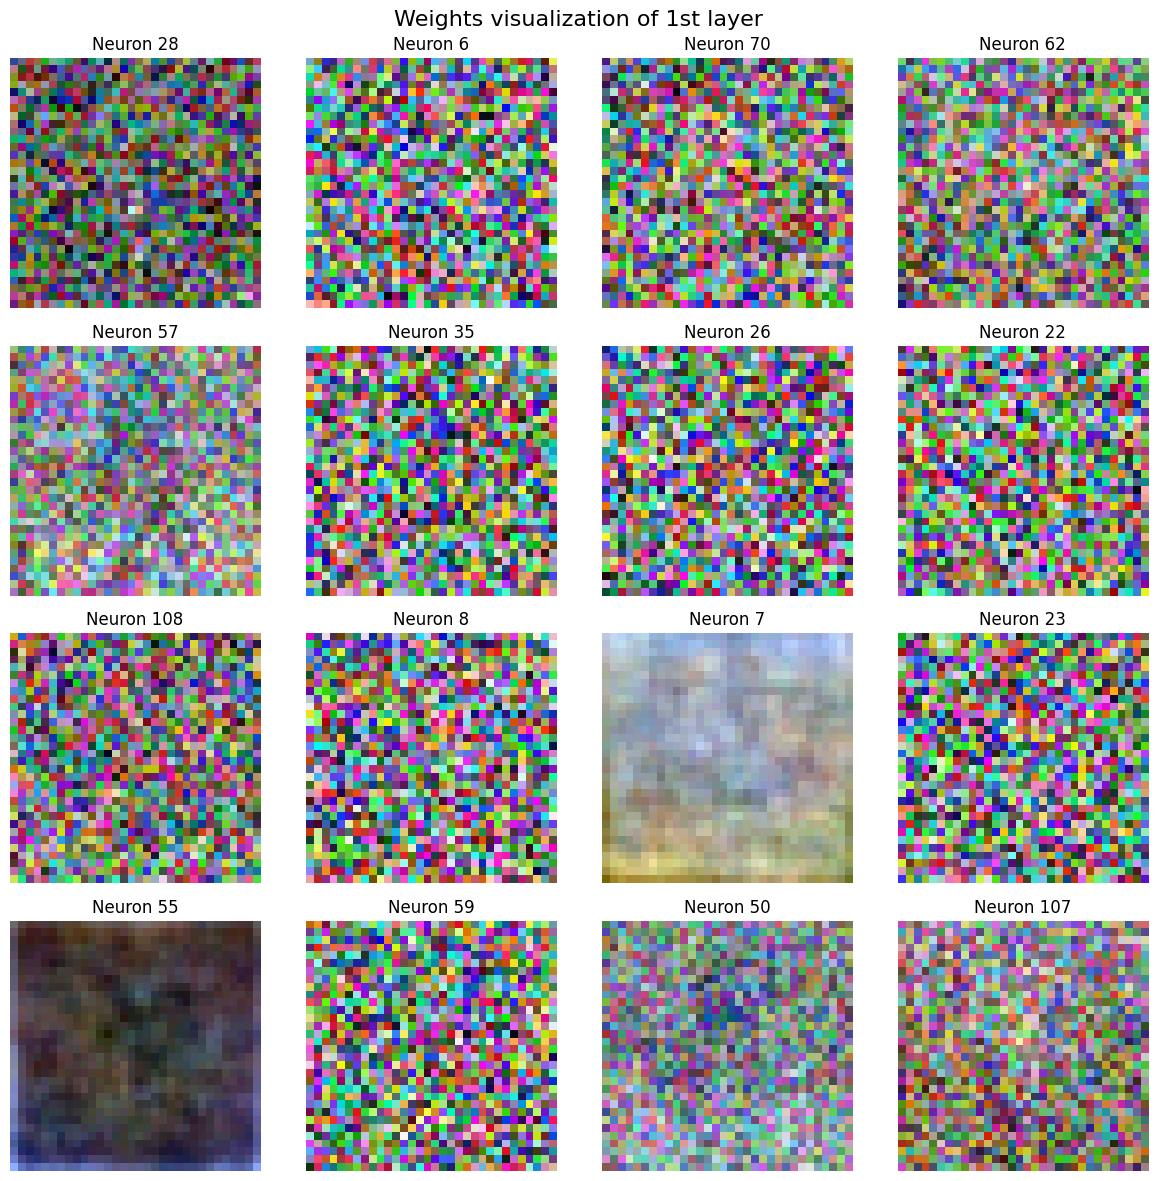

In [62]:
weights = best_model.linear_relu_stack[0].weight.data.cpu()

weights_reshaped = weights.view(128, 3, 32, 32)
random_neurons = random.sample(range(128), 16)  # choose 16 random neurons

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i, neuron_idx in enumerate(random_neurons):
    w = weights_reshaped[neuron_idx]

    # Min-Max Scaling
    w_min = w.min()
    w_max = w.max()
    w_norm = (w - w_min) / (w_max - w_min)

    w_img = w_norm.permute(1, 2, 0).numpy()

    axes[i].imshow(w_img)
    axes[i].axis('off')
    axes[i].set_title(f'Neuron {neuron_idx}')

plt.suptitle("Weights visualization of 1st layer", fontsize=16)
plt.tight_layout()
plt.show()

## Convonutional Neural Networks

### Baseline CNN

In [63]:
# baseline CNN

import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # feature extraction
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=0)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=0)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=0)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=0)

        # fully connected head
        self.fc1 = nn.Linear(in_features=128*16*16, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        # feature extraction
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layers
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

baseline_cnn_model = BaselineCNN().to(device)
# debugging
print(baseline_cnn_model)

BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=32768, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)


### Training

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

optimizer_cnn = Adam(baseline_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_cnn = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_cnn = -1
best_model_path_cnn = 'best_baseline_cnn.pth'

print("Starting training for baseline CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(baseline_cnn_model, train_dataloader, optimizer_cnn, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(baseline_cnn_model, val_dataloader, criterion)

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_acc'].append(val_acc)
    history_cnn['val_f1'].append(val_f1)

    if val_f1>best_val_f1_cnn:
        best_val_f1_cnn = val_f1
        torch.save(baseline_cnn_model.state_dict(), best_model_path_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for baseline CNN model...
Epoch [1/30]  Train Loss: 1.5881 | Train Acc: 32.97% | Val Loss: 1.3590 | Val Acc: 33.88% | Val F1: 0.3065
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3246 | Train Acc: 38.44% | Val Loss: 1.3283 | Val Acc: 37.25% | Val F1: 0.3208
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.3390 | Train Acc: 37.09% | Val Loss: 1.3247 | Val Acc: 38.12% | Val F1: 0.3638
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.3217 | Train Acc: 38.91% | Val Loss: 1.3118 | Val Acc: 41.62% | Val F1: 0.3799
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.3193 | Train Acc: 37.97% | Val Loss: 1.3598 | Val Acc: 36.00% | Val F1: 0.333

### Learning curves (Loss and F1-macro)

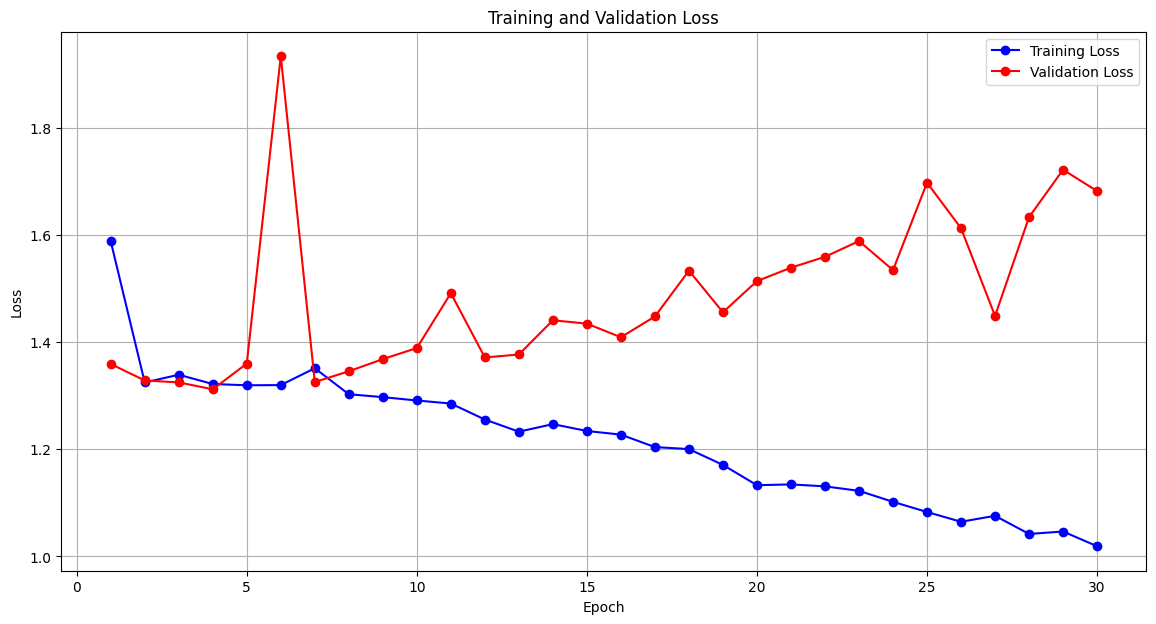

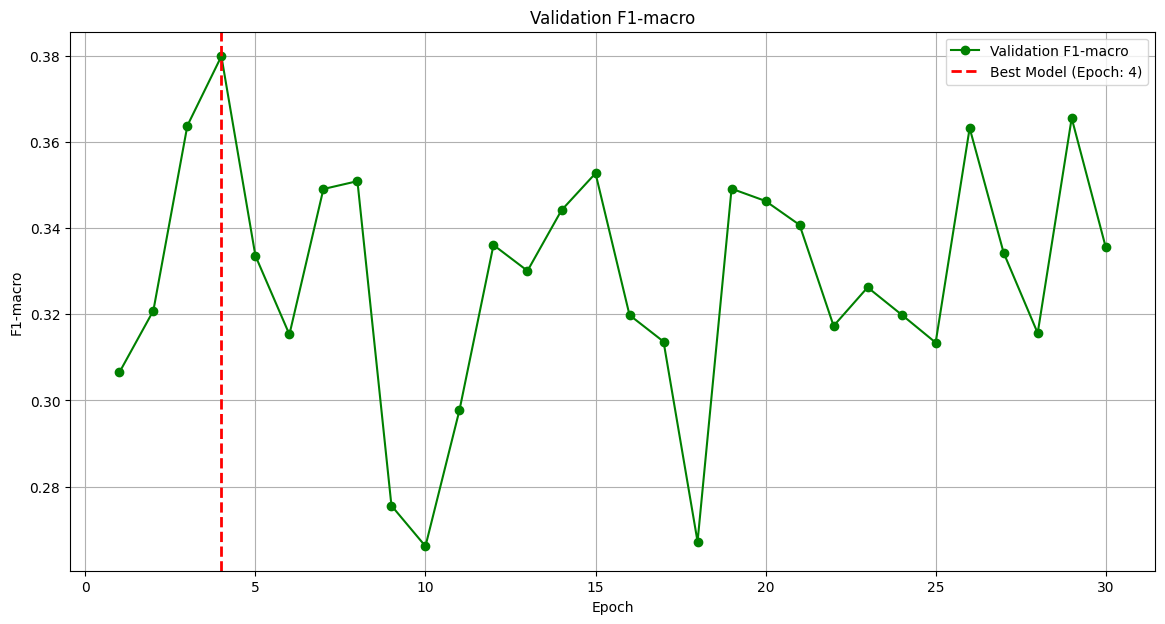

In [65]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['train_loss'])+1), history_cnn['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_cnn['val_loss'])+1), history_cnn['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['val_f1'])+1), history_cnn['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_cnn['val_f1'].index(max(history_cnn['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

### Best baseline CNN model evaluation on test set

=======  Baseline CNN model evaluation on TEST SET  =======
Test Loss: 1.3231948021480016
Test Accuracy: 0.39785714285714285
Test F1-macro: 0.3653452672055688
Test Confusion matrix:
[170  69  23  88]
[ 60 189  18  83]
[ 84 111  22 133]
[ 64  86  24 176]



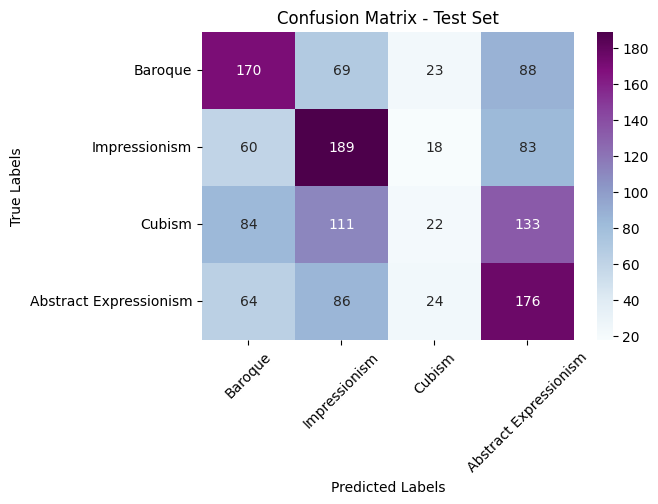


Total number of parameters: 34096452


In [66]:
# best baseline cnn evaluation on test set

best_baseline_cnn = BaselineCNN().to(device)
best_baseline_cnn.load_state_dict(torch.load(best_model_path_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_baseline_cnn, test_dataloader, criterion)

print("=======  Baseline CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_baseline_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

### Pooling CNN

In [67]:
class PoolingCNN(nn.Module):
    def __init__(self):
        super(PoolingCNN, self).__init__()

        # every convolutional layer (with kernel_size=5 and padding=2) keeps the resolution the same but changes the number of channels (3->16->32...)
        # every max_pooling layer (with kernel_size=2) keeps the number of channels the same but halves both dimensions (1/4 of the resolution: 32x32->16x16->8x8...)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = self.pool4(self.conv4(x))

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

# debugging
pooling_cnn_model = PoolingCNN().to(device)
print(pooling_cnn_model)

PoolingCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)


### Training

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pooling_optimizer = Adam(pooling_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_pooling = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_pooling_cnn = -1
best_model_path_pooling_cnn = 'best_pooling_cnn.pth'

print("Starting training for pooling CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(pooling_cnn_model, train_dataloader, pooling_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(pooling_cnn_model, val_dataloader, criterion)

    history_pooling['train_loss'].append(train_loss)
    history_pooling['train_acc'].append(train_acc)
    history_pooling['val_loss'].append(val_loss)
    history_pooling['val_acc'].append(val_acc)
    history_pooling['val_f1'].append(val_f1)

    if val_f1>best_val_f1_pooling_cnn:
        best_val_f1_pooling_cnn = val_f1
        torch.save(pooling_cnn_model.state_dict(), best_model_path_pooling_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for pooling CNN model...
Epoch [1/30]  Train Loss: 1.3745 | Train Acc: 29.03% | Val Loss: 1.3054 | Val Acc: 43.12% | Val F1: 0.3926
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.2469 | Train Acc: 43.16% | Val Loss: 1.1479 | Val Acc: 48.12% | Val F1: 0.4473
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.0952 | Train Acc: 53.03% | Val Loss: 1.1023 | Val Acc: 52.00% | Val F1: 0.5012
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 0.9782 | Train Acc: 59.00% | Val Loss: 1.0592 | Val Acc: 54.12% | Val F1: 0.5242
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 0.8776 | Train Acc: 64.16% | Val Loss: 1.0473 | Val Acc: 55.75% | Val F1: 0.5449

### Learning curves (Loss and F1-macro)

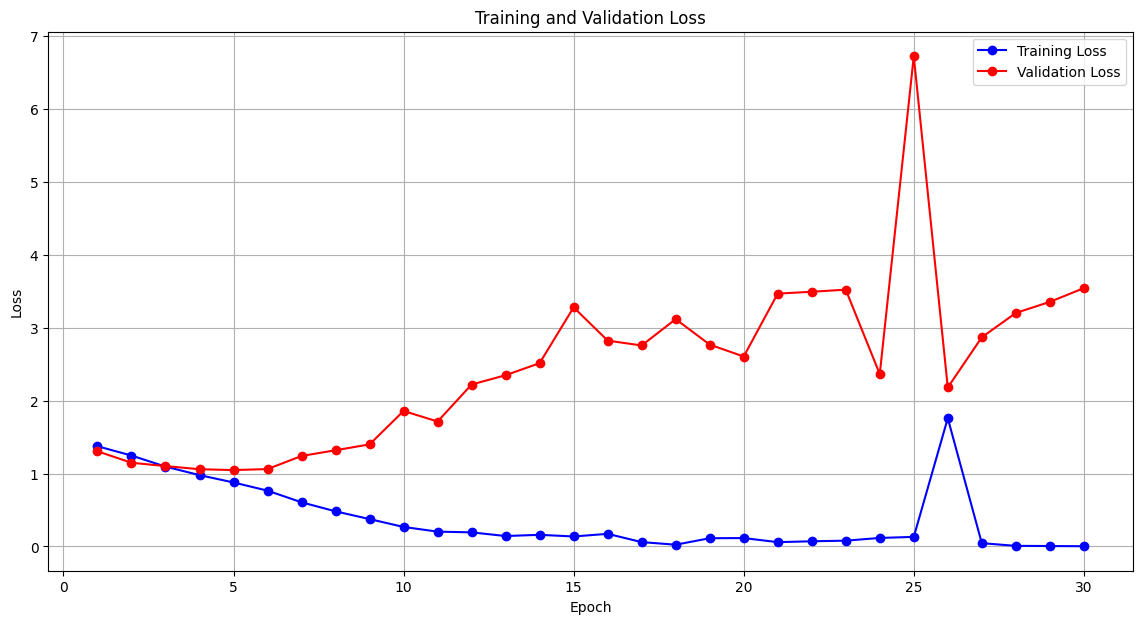

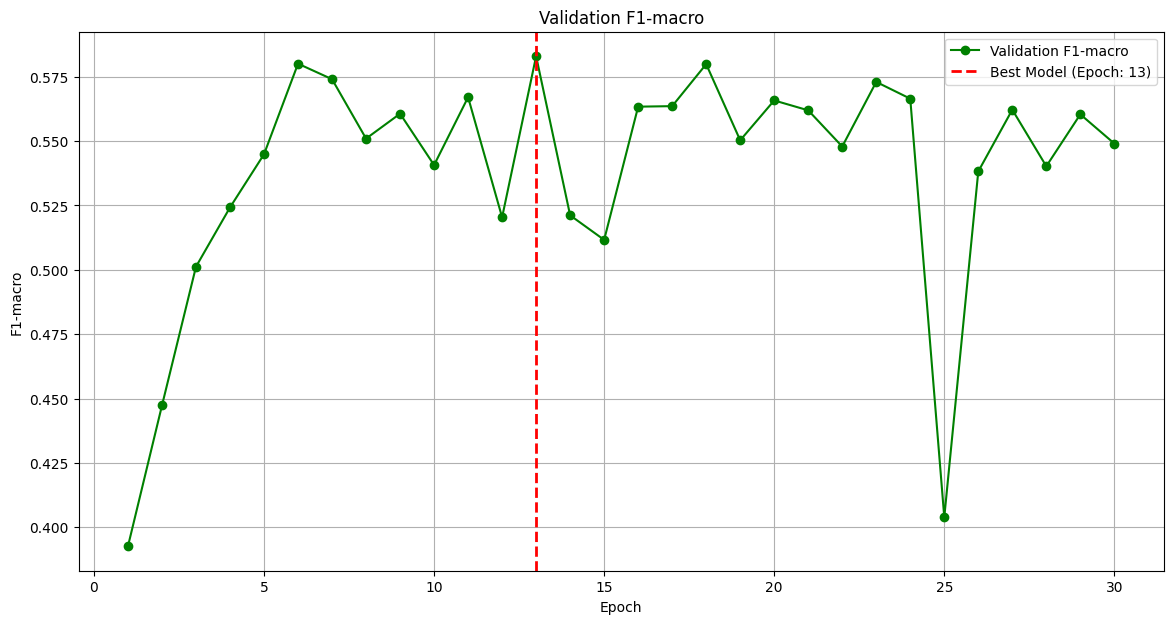

In [69]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['train_loss'])+1), history_pooling['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_pooling['val_loss'])+1), history_pooling['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['val_f1'])+1), history_pooling['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_pooling['val_f1'].index(max(history_pooling['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

### Best Pooling CNN model evaluation on test set

=======  Pooling CNN model evaluation on TEST SET  =======
Test Loss: 2.170047791344779
Test Accuracy: 0.5864285714285714
Test F1-macro: 0.5844988249613853
Test Confusion matrix:
[259  31  32  28]
[ 35 215  61  39]
[ 25  67 202  56]
[ 22  76 107 145]



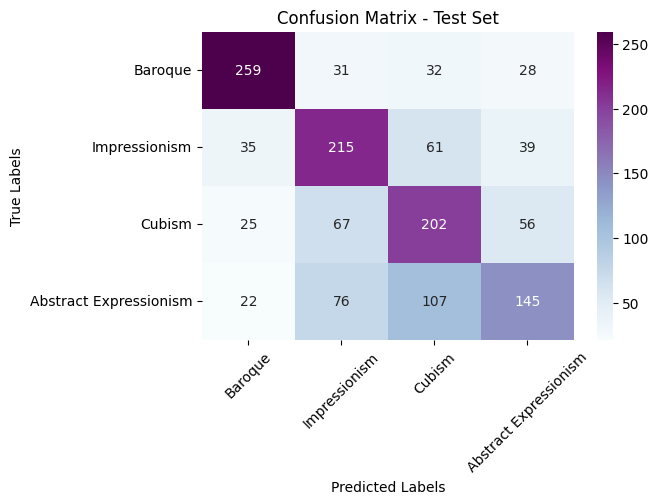


Total number of parameters: 1066308


In [70]:
# best pooling cnn model evaluation on test set

best_pooling_cnn = PoolingCNN().to(device)
best_pooling_cnn.load_state_dict(torch.load(best_model_path_pooling_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_pooling_cnn, test_dataloader, criterion)

print("=======  Pooling CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_pooling_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

### CNN with activations

In [71]:
class ActivationCNN(nn.Module):
    def __init__(self):
        super(ActivationCNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.pool4(self.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

# debugging
activation_cnn_model = ActivationCNN().to(device)
print(activation_cnn_model)

ActivationCNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)


### Training

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

activation_cnn_optimizer = Adam(activation_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_activation = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_activation_cnn = -1
best_model_path_activation_cnn = 'best_activation_cnn.pth'

print("Starting training for activation CNN model...")

gpu_time = -1
cpu_time = -1
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(activation_cnn_model, train_dataloader, activation_cnn_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(activation_cnn_model, val_dataloader, criterion)

    history_activation['train_loss'].append(train_loss)
    history_activation['train_acc'].append(train_acc)
    history_activation['val_loss'].append(val_loss)
    history_activation['val_acc'].append(val_acc)
    history_activation['val_f1'].append(val_f1)

    if val_f1>best_val_f1_activation_cnn:
        best_val_f1_activation_cnn = val_f1
        torch.save(activation_cnn_model.state_dict(), best_model_path_activation_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

end_time = time.time()
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

print("Training complete!")

Using device: cuda
Starting training for activation CNN model...
Epoch [1/30]  Train Loss: 1.3369 | Train Acc: 30.78% | Val Loss: 1.2844 | Val Acc: 34.62% | Val F1: 0.2442
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.2804 | Train Acc: 36.00% | Val Loss: 1.2721 | Val Acc: 36.75% | Val F1: 0.2666
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2428 | Train Acc: 38.28% | Val Loss: 1.2458 | Val Acc: 38.88% | Val F1: 0.3206
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.1999 | Train Acc: 42.44% | Val Loss: 1.1977 | Val Acc: 47.38% | Val F1: 0.4088
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.1461 | Train Acc: 45.88% | Val Loss: 1.1397 | Val Acc: 49.62% | Val F1: 0.4

### Training on CPU

In [73]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    activation_cnn_cpu = ActivationCNN().to(device)
    optimizer_activation_cnn_cpu = Adam(activation_cnn_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(activation_cnn_cpu, train_dataloader, optimizer_activation_cnn_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 293.53 seconds
GPU was 10.3747 times quicker than the CPU


### Learning curves (Loss and F1-macro)

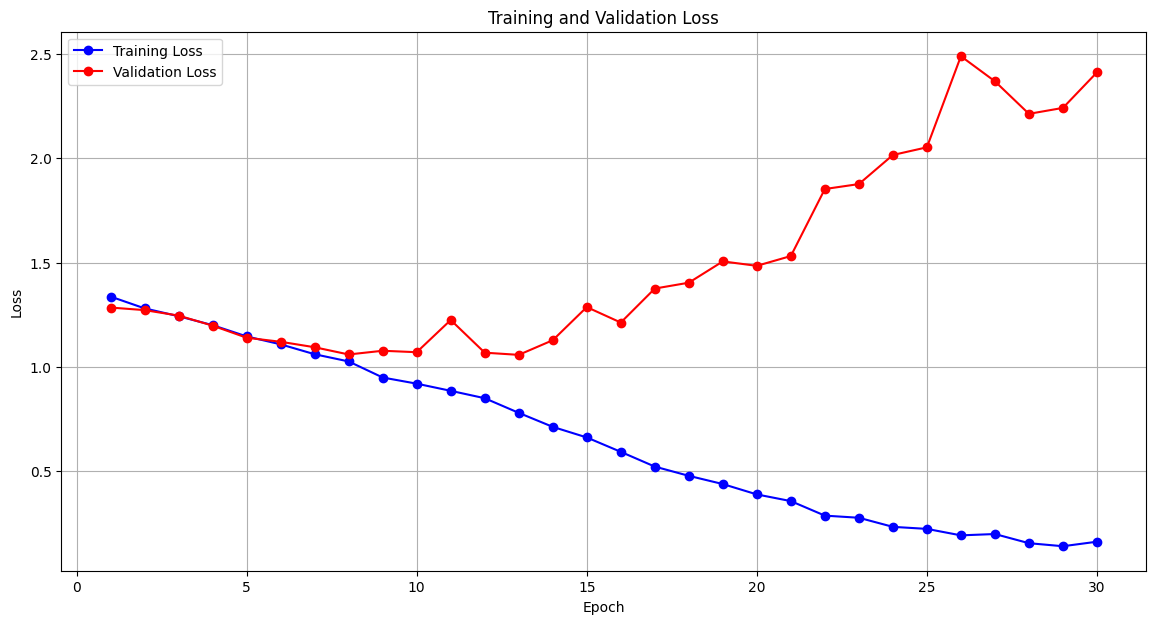

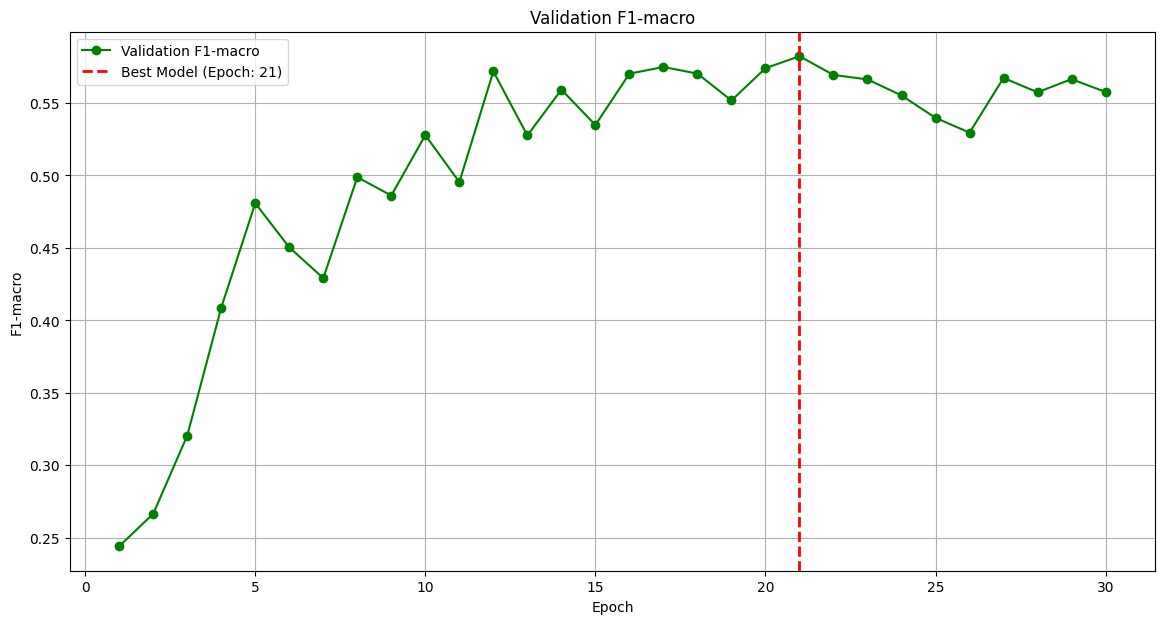

In [74]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['train_loss'])+1), history_activation['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_activation['val_loss'])+1), history_activation['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['val_f1'])+1), history_activation['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_activation['val_f1'].index(max(history_activation['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

### Best Activation CNN model evaluation on the test set

=======  Activation CNN model evaluation on TEST SET  =======
Test Loss: 1.4281408429145812
Test Accuracy: 0.5978571428571429
Test F1-macro: 0.5984898836691702
Test Confusion matrix:
[245  34  37  34]
[ 18 196  69  67]
[ 31  40 152 127]
[ 19  26  61 244]



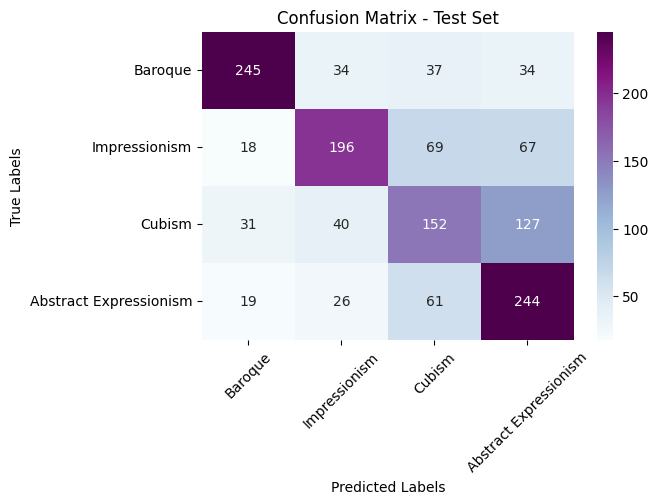


Total number of parameters: 1066308


In [75]:
# best activation cnn model evaluation on test set

best_activation_cnn = ActivationCNN().to(device)
best_activation_cnn.load_state_dict(torch.load(best_model_path_activation_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_activation_cnn, test_dataloader, criterion)

cm_cnn = test_cm

print("=======  Activation CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_activation_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

### Q2.1 Συμπληρώστε τον πίνακα. Ποια αλλαγή είχε τη μεγαλύτερη επίδραση στην επίδοση και ποια στον αριθμό παραμέτρων; Αν η §2.1 πετυχαίνει χαμηλή ή σχεδόν τυχαία απόδοση, εξηγήστε τεχνικά γιατί συμβαίνει αυτό, πέρα από τη γενική παρατήρηση ότι λείπουν τα activations.

**A:**
| Έκδοση | #params | Val Acc | Test Acc | F1 macro |
| :--- | :--- | :--- | :--- | :--- |
| §2.1 (χωρίς pad/pool/activ) | 34096452 | 41.62% | 39.78% | 0.3653 |
| §2.2 (με pad και pool) | 1066308 | 58.50% | 58.64% | 0.5844 |
| §2.3 (με ReLU) | 1066308 | 58.13% | 59.78% | 0.5984 |

**Για τον αριθμό παραμέτρων, η προσθήκη του Max Pooling (2.2) επέφερε την μεγαλύτερη επίδραση. Η σταδιακή μείωση των διαστάσεων από 32x32 σε 2x2, είχε ως αποτέλεσμα το flatten να δώσει πολύ μικρότερο διάνυσμα εισόδου (128\*2\*2=512 αντί για 128\*16\*16=32768) στα fully connected layers. Έτσι ο αριθμός των παραμέτρων μειώθηκε από ~34 εκατομμύρια σε ~1 εκατομμύριο (-97%).**

**Για την επίδοση (Accuracy/F1-macro), η μεγαλύτερη επίδραση προέρχεται από τον συνδυασμό Padding/Max Pooling. Αυτή η προσθήκη επέτρεψε στο δίκτυο να ξεφύγει από το σχεδόν τυχαίο baseline φτάνοντας κοντά στο ~58%.**

**Η προσθήκη της ReLU ως activation function δεν επηρέασε καθόλου τον αριθμό των παραμέτρων από την έκδοση 2.2 καθώς είναι απλά μία μαθηματική συνάρτηση χωρίς εκπαιδεύσιμα βάρη ή biases. Βελτιώνει την ποιότητα της μάθησης (γενικευσιμότητα) και αυτό φαίνεται από την αύξηση στις μετρικές των αποτελεσμάτων.**

**Η έκδοση 2.1 πετυχαίνει χαμηλή (σχεδόν τυχαία) επίδοση κυρίως για τους εξής λόγους:**
1. **Γραμμικότητα:** Χωρίς activation function, η διαδοχή συνελικτικών και γραμμικών επιπέδων είναι ισοδύναμη με ένα απλό, ενιαίο γραμμικό επίπεδο (Linear Classifier). Ένα τέτοιο μοντέλο στερείται της ικανότητας να μάθει περίπλοκα, μη-γραμμικά μοτίβα (σκιές, υφές, καμπύλες, τεχνοτροπίες) που υπάρχουν στους πίνακες του dataset.
2. **Τοπικότητα:** Χωρίς max pooling, το δίκτυο δεν μπορεί να αποκτήσει ανθεκτικότητα στη θέση των χαρακτηριστικών. Αν ένα μοτίβο μετατοπιστεί έστω και λίγα pixel σε εικόνες εκτός του training set, το δίκτυο αδυνατεί να το αναγνωρίσει.
3. **Απώλεια πληροφορίας στα άκρα:** Χωρίς padding, τα pixels στα όρια της εικόνας υποεκπροσωπούνται κατά τη συνέλιξη και η χωρική πληροφορία μειώνεται σε κάθε layer, περιορίζοντας τη δυνατότητα των βαθύτερων επιπέδων να εξάγουν σωστά χαρακτηριστικά από ολόκληρη την εικόνα.

Total number of parameters for baseline FNN model: 397604



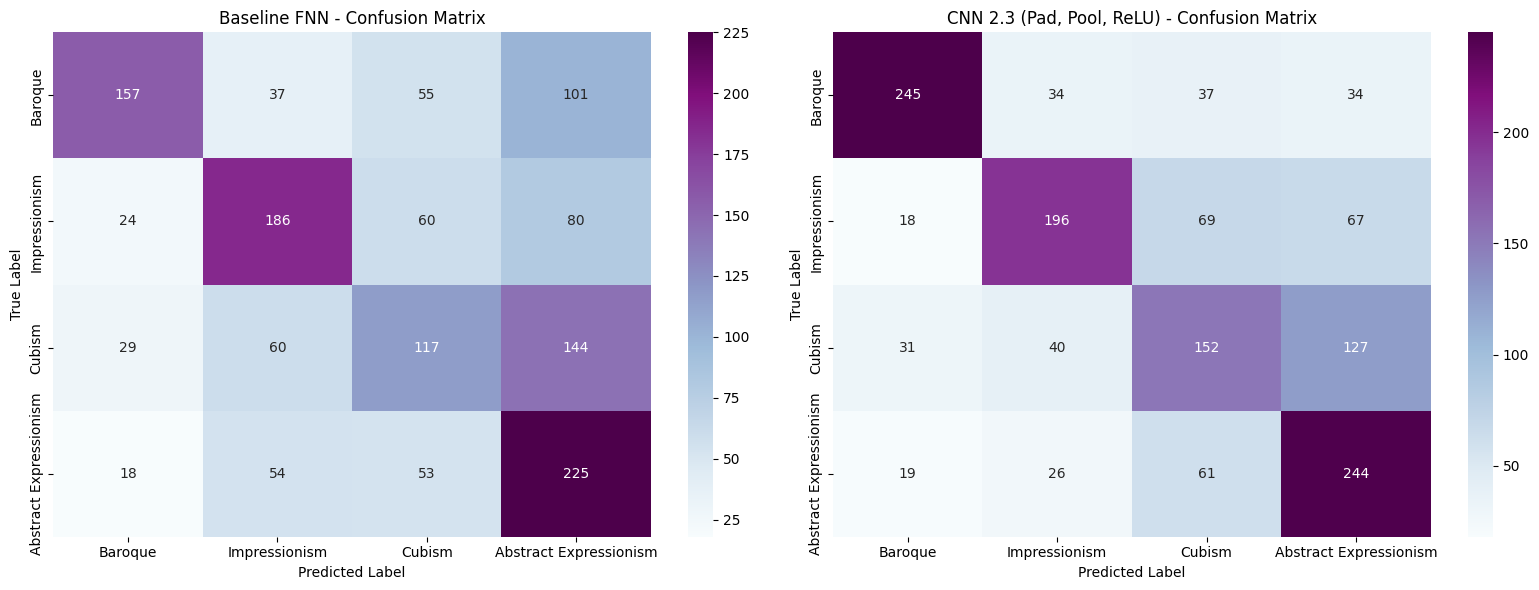

In [81]:
# number of parameters for baseline fnn
total_parameters_fnn = sum(p.numel() for p in best_model.parameters())
print(f"Total number of parameters for baseline FNN model: {total_parameters_fnn}\n")

# 2 confusion matrices plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.heatmap(cm_fnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline FNN - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('CNN 2.3 (Pad, Pool, ReLU) - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Q2.2 Συγκρίνετε το τελικό CNN (§2.3) με το FFN του Ερωτήματος 1 σε δύο μετρικές: τον αριθμό των παραμέτρων και το test F1 macro. Το CNN έχει περισσότερες ή λιγότερες παραμέτρους από το FFN; Πόσο διαφορετική είναι η επίδοση; Συζητήστε γιατί ο αριθμός των παραμέτρων από μόνος του δεν προβλέπει την επίδοση, και ποιο ρόλο παίζει εδώ η δομή των παραμέτρων (πώς οργανώνονται και ποια prior knowledge κωδικοποιούν για εικόνες). Συγκρίνετε επίσης τα confusion matrices: σε ποια κινήματα βελτιώνεται ουσιαστικά το CNN; Πώς συγκρίνεται το CPU-vs-GPU speedup του CNN με αυτό του FFN, και γιατί;  


**A:**
| Μοντέλο | #params | Test F1-macro |
| :--- | :--- | :--- |
| Baseline FNN | 397604 | 0.4883 |
| CNN με pad, pool και ReLU | 1066308 | 0.5984 |


**Το CNN έχει περισσότερες παραμέτρους από το FFN 1.066.308 έναντι 397.604 αντίστοιχα (περίπου 2.7 φορές περισσότερες).**  
**Το CNN πετυχαίνει επίσης αρκετά καλύτερη επίδοση, με το F1-macro να ανεβαίνει από το 0.4883 στο 0.5984 (περίπου +11%).**

**Επειδή στο FFN η εικόνα γίνεται flat, κάθε νευρώνας συνδέεται με όλα τα pixel. Έτσι προσπαθεί να βρει global patterns σε μια flat λίστα από pixels, αγνοώντας ποια pixel είναι γειτονικά. Το CNN οργανώνει τις παραμέτρους του σε 2D φίλτρα (kernels) και αυτή η δομή καταφέρνει να κωδικοποιήσει δύο σημαντικές γνώσεις για τις εικόνες:**
1. **Τοπικότητα:** τα φίλτρα επεξεργάζονται γειτονικά pixels (π.χ. σε 5x5 τετράγωνα) για να καλύψουν πληροφορία όπως πινελιές, σχήματα, ακμές, καμπύλες.
2. **Μοιρασμένα βάρη:** ολόκληρη η εικόνα σκανάρεται από ακριβώς το ίδιο φίλτρο κάθε φορά. Έτσι το μοντέλο αν μάθει για παράδειγμα, μια κυβιστική γωνία, θα μπορεί να την αναγνωρίσει οπουδήποτε σε έναν νέο πίνακα.

**Συνεπώς, ο αριθμός των παραμέτρων δεν προβλέπει την επίδοση καθώς στο baseline FNN, οι παράμετροι σπαταλούνται σε flat συνδέσεις που δεν μπορούν να μάθουν οπτικά μοτίβα. Αντίθετα στο CNN με padding, pooling και ReLU, οι παράμετροι είναι όλες εξ αρχής δομημένες ώστε να εντοπίσουν και να μάθουν οπτική και χωρική πληροφορία.**

**Παρατηρώντας τα confusion matrices, το τελικό CNN παρουσιάζει βελτίωση και στα 4 κινήματα. Στους πίνακες Μπαρόκ και Κυβισμού φαίνεται η μεγαλύτερη αύξηση των σωστών προβλέψεων: +88 πίνακες και +35 πίνακες αντίστοιχα. Στα άλλα δύο κινήματα υπάρχει μικρότερη αύξηση σωστών προβλέψεων στους +19 πίνακες (Αφηρημένος Εξπρεσιονισμός) και +11 πίνακες (Ιμπρεσιονισμός).**

**Το 2.3 CNN επιτυγχάνει σημαντικά μεγαλύτερο speedup στην GPU (περίπου 10 φορές ταχύτερη εκπαίδευση) σε σχέση με το baseline FFN (περίπου 2-3 φορές ταχύτερη εκπαίδευση). Η πράξη της συνέλιξης αποτελείται από πολλούς, ανεξάρτητους και τοπικούς element-wise πολλαπλασιασμούς. Η αρχιτεκτονική της GPU με χιλιάδες μικρούς πυρήνες είναι ιδανική για την μαζική παράλληλη εκτέλεση αυτών των αυτόνομων πράξεων. Αντίθετα, το FFN εκτελεί μεγάλους πολλαπλασιασμούς πινάκων που δημιουργούν bottlenecks στη μεταφορά δεδομένων (memory bandwidth) με αποτέλεσμα να μην μπορεί να εκμεταλλευτεί πλήρως την δυνατότητα πλήρους παραλληλισμού.**

### Q2.3 Σενάριο: Ένα μουσείο σχεδιάζει σύστημα αυτόματης υφολογικής ταξινόμησης για ψηφιοποιημένη συλλογή 2.000.000 έργων. Σας προτείνεται να βαθύνετε το δίκτυο (δέκα συνελικτικά επίπεδα αντί για τέσσερα), με αναμενόμενο όφελος +2% στο test accuracy αλλά πολλαπλάσιο computational cost. Βασιστείτε στους χρόνους CPU/GPU που μετρήσατε (§1 και §2.3) και στο train–val behavior που παρατηρήσατε. Σε ποιες περιπτώσεις είναι λογική αυτή η επιλογή και σε ποιες όχι; Σκεφτείτε deployment context (real-time έναντι batch processing), κόστος ενέργειας, και ανάγκη ερμηνευσιμότητας από επιμελητές.

**Α:**